# Evaluate distance based confidence predictor performance

In [1]:
import re

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

In [2]:
with open('data/logs/train_confidence_predictor.log') as fh:
    training_log = fh.read()

In [3]:
print(training_log)

2025-01-31 16:21:58,076 - INFO: Parameter: training_data='data/processed/sequences.h5'
2025-01-31 16:21:58,076 - INFO: Parameter: output='models/ConfidencePredictor/model.onnx'
2025-01-31 16:21:58,076 - INFO: Parameter: test_size=0.15
2025-01-31 16:21:58,076 - INFO: Parameter: seed=None
2025-01-31 16:21:58,076 - INFO: Parameter: log_level='info'
2025-01-31 16:21:58,076 - INFO: Parameter: log_file='data/logs/train_confidence_predictor.log'
2025-01-31 16:21:58,076 - INFO: Loading data...
2025-01-31 16:22:02,428 - INFO: Computing distances
2025-01-31 17:21:35,869 - INFO: Test indices: [51309, 22059, 11242, 77587, 70053, 1183, 25165, 15469, 6347, 24183, 79192, 24781, 28897, 47912, 36361, 78475, 76216, 62811, 38974, 62122, 58358, 13610, 22262, 34516, 71826, 14893, 42280, 74258, 83705, 76048, 27968, 64036, 11344, 62239, 20248, 5752, 61129, 54527, 13273, 12214, 54519, 53176, 65915, 71659, 64699, 68234, 26542, 3126, 51220, 38336, 23522, 13735, 71428, 14200, 2784, 62694, 20919, 48303, 76490, 62

In [4]:
folds = [int(fold) for fold in re.findall(r'INFO: Starting model for fold (\d+)', training_log, flags=re.MULTILINE)]

In [5]:
r_squareds = [float(val) for val in re.findall(r'INFO: R\^2: (\d+\.\d+)', training_log, flags=re.MULTILINE)]

In [6]:
rmses = [float(val) for val in re.findall(r'INFO: RMSE: (\d+\.\d+)', training_log, flags=re.MULTILINE)]

In [7]:
results = pd.DataFrame(
    {
        'fold': folds,
        'r_squared': r_squareds,
        'rmse': rmses,
    }
)

results

,fold,r_squared,rmse
0,1,0.982440,0.023048
1,2,0.975566,0.022810
2,3,0.969635,0.023259
3,4,0.975769,0.024195
4,5,0.977130,0.023954


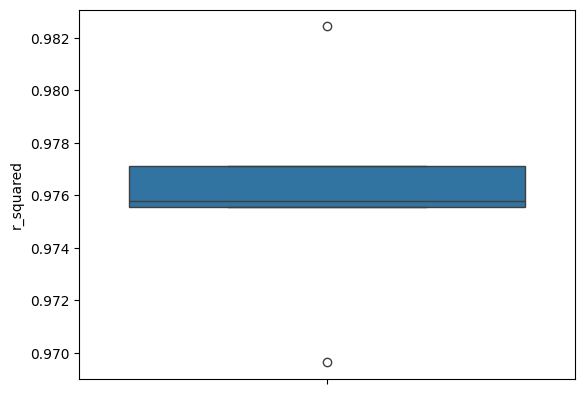

count    5.000000
mean     0.976108
std      0.004567
min      0.969635
25%      0.975566
50%      0.975769
75%      0.977130
max      0.982440
Name: r_squared, dtype: float64

In [8]:
sns.boxplot(results, y='r_squared')

plt.show()
results['r_squared'].describe()

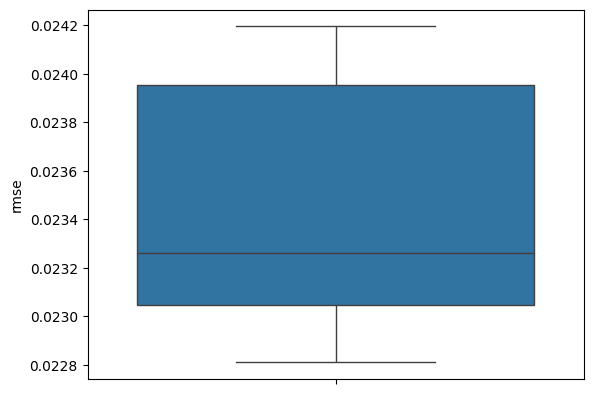

count    5.000000
mean     0.023453
std      0.000595
min      0.022810
25%      0.023048
50%      0.023259
75%      0.023954
max      0.024195
Name: rmse, dtype: float64

In [9]:
sns.boxplot(results, y='rmse')

plt.show()
results['rmse'].describe()